In [20]:
import warnings
warnings.filterwarnings("ignore")

# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Preprocessing
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
)
from sklearn.pipeline import Pipeline

# Classification
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    RandomForestRegressor, GradientBoostingRegressor
)
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVC, SVR
from sklearn.linear_model import LogisticRegression, Ridge, Lasso, LinearRegression

# Metriques
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    mean_squared_error, mean_absolute_error, r2_score
)


# SHAP
try:
    import shap
    SHAP_AVAILABLE = True
    print("SHAP disponible")
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP non installe -- pip install shap")


SHAP disponible



#  MODULE 2 : Modélisation Supervisée

## Partie 1 : Préparation des Données — Split 70 / 15 / 15 (stratifié)

> **Ratio** : 70% Train | 15% Validation | 15% Test  
> **Stratification** sur `Categorie` pour préserver la distribution des classes.  
> Le **set de validation** sert au tuning, le **test** à l'évaluation finale.

In [21]:
import pandas as pd

df_clean = pd.read_csv("../data/df_clean2.csv")

In [22]:
#feature_cols = ['Poids', 'Volume','Opacite','Conductivite']

In [23]:
#df_clean = df_clean.drop_duplicates(subset=feature_cols, keep='first')

In [24]:
feature_cols = [c for c in df_clean.columns if c not in [
    'Categorie',        
    'Rapport_Collecte', 
    'Prix_Revente'
]]
X = df_clean[feature_cols].copy()
y = df_clean['Categorie'].copy()


# 1. SPLIT d'abord (sur données brutes)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"\nSplit terminé:")
print(f"  Train : {X_train.shape}")
print(f"  Val   : {X_val.shape}")
print(f"  Test  : {X_test.shape}")


Split terminé:
  Train : (6806, 6)
  Val   : (1459, 6)
  Test  : (1459, 6)



## Mise à l'echelle

In [25]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"\n Standardisation terminée (fit sur Train uniquement)")
print(f"  Train mean: {X_train_scaled.mean():.2e}")
print(f"  Test mean:  {X_test_scaled.mean():.2e}")


 Standardisation terminée (fit sur Train uniquement)
  Train mean: -4.78e-18
  Test mean:  9.87e-03



## Partie 2 : Classification — Entrainement et Evaluation

### 2.1 — Random Forest

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
print("\n=== RANDOM FOREST ===")

rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf, average='weighted')
rf_rec = recall_score(y_test, y_pred_rf, average='weighted')
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')

print("Confusion matrix RF:\n", confusion_matrix(y_test, y_pred_rf))
print("Accuracy RF:", rf_acc)
print("Precision RF:", rf_prec)
print("Recall RF:", rf_rec)
print("F1-score RF:", rf_f1)

print("\nClassification Report RF:\n")
print(classification_report(y_test, y_pred_rf))


=== RANDOM FOREST ===
Confusion matrix RF:
 [[325   0   0   0]
 [  0 315   0   0]
 [ 14  12 420  15]
 [  0   0   0 358]]
Accuracy RF: 0.971898560657985
Precision RF: 0.9730101132433855
Recall RF: 0.971898560657985
F1-score RF: 0.9715281762515751

Classification Report RF:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       325
           1       0.96      1.00      0.98       315
           2       1.00      0.91      0.95       461
           3       0.96      1.00      0.98       358

    accuracy                           0.97      1459
   macro avg       0.97      0.98      0.97      1459
weighted avg       0.97      0.97      0.97      1459



### 2.2 — Gradient Boosting Classifier

In [27]:
gbc = GradientBoostingClassifier(
    n_estimators=50,
    learning_rate=0.05,
    max_depth=2,
    random_state=42
)

gbc.fit(X_train_scaled, y_train)

y_pred_gbc = gbc.predict(X_test_scaled)

gbcl_acc = accuracy_score(y_test, y_pred_gbc)
gbcl_prec = precision_score(y_test, y_pred_gbc, average='weighted')
gbcl_rec = recall_score(y_test, y_pred_gbc, average='weighted')
gbcl_f1 = f1_score(y_test, y_pred_gbc, average='weighted')

print("Confusion Matrix GBC:\n", confusion_matrix(y_test, y_pred_gbc))
print("\nAccuracy GBC:", gbcl_acc)
print("Precision GBC:", gbcl_prec)
print("Recall GBC:", gbcl_rec)
print("F1-score GBC:", gbcl_f1)

print("\nClassification Report GBC:\n")
print(classification_report(y_test, y_pred_gbc))

Confusion Matrix GBC:
 [[325   0   0   0]
 [  0 315   0   0]
 [ 15  19 411  16]
 [  0   0   0 358]]

Accuracy GBC: 0.9657299520219328
Precision GBC: 0.9673934852692565
Recall GBC: 0.9657299520219328
F1-score GBC: 0.9651738658441923

Classification Report GBC:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       325
           1       0.94      1.00      0.97       315
           2       1.00      0.89      0.94       461
           3       0.96      1.00      0.98       358

    accuracy                           0.97      1459
   macro avg       0.96      0.97      0.97      1459
weighted avg       0.97      0.97      0.97      1459



### 2.3 — k-NN (k optimé sur la validation)

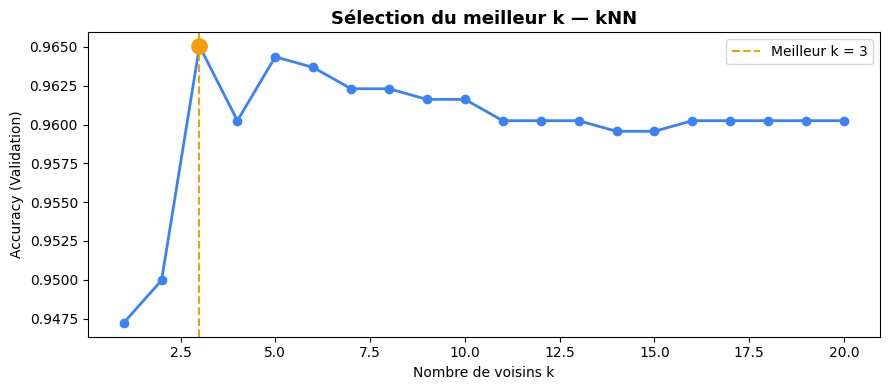


=== KNN FINAL (k = 3) ===
Accuracy  : 0.9561
Precision : 0.9571
Recall    : 0.9561
F1-score  : 0.9555

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       325
           1       0.94      0.99      0.96       315
           2       0.98      0.88      0.93       461
           3       0.95      0.99      0.97       358

    accuracy                           0.96      1459
   macro avg       0.95      0.96      0.96      1459
weighted avg       0.96      0.96      0.96      1459


=== LIGNE TABLEAU ===
['KNN (k=3)', 0.956, 0.957, 0.956, 0.955]


In [28]:
# ===============================
# 1. IMPORTS
# ===============================
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# ===============================
# 2. PALETTE (FIX ERREUR)
# ===============================
PALETTE = ["#3B82F6", "#10B981", "#F59E0B", "#EF4444"]

# ===============================
# 3. SELECTION DU MEILLEUR k
# ===============================
k_range = range(1, 21)
scores_k = []

for k in k_range:
    knn_tmp = KNeighborsClassifier(n_neighbors=k)
    knn_tmp.fit(X_train_scaled, y_train)
    scores_k.append(accuracy_score(y_val, knn_tmp.predict(X_val_scaled)))

best_k = list(k_range)[scores_k.index(max(scores_k))]

# ===============================
# 4. GRAPHIQUE k
# ===============================
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(k_range), scores_k, marker='o', color=PALETTE[0], linewidth=2)

ax.axvline(best_k, color=PALETTE[2], linestyle='--', label=f'Meilleur k = {best_k}')
ax.scatter([best_k], [max(scores_k)], color=PALETTE[2], s=120, zorder=5)

ax.set_xlabel("Nombre de voisins k")
ax.set_ylabel("Accuracy (Validation)")
ax.set_title("Sélection du meilleur k — kNN", fontsize=13, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

# ===============================
# 5. MODELE FINAL
# ===============================
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

# ===============================
# 6. METRICS
# ===============================
knn_acc  = accuracy_score(y_test, y_pred_knn)
knn_prec = precision_score(y_test, y_pred_knn, average='weighted')
knn_rec  = recall_score(y_test, y_pred_knn, average='weighted')
knn_f1   = f1_score(y_test, y_pred_knn, average='weighted')

# ===============================
# 7. AFFICHAGE
# ===============================
print(f"\n=== KNN FINAL (k = {best_k}) ===")
print(f"Accuracy  : {knn_acc:.4f}")
print(f"Precision : {knn_prec:.4f}")
print(f"Recall    : {knn_rec:.4f}")
print(f"F1-score  : {knn_f1:.4f}")

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred_knn))

# ===============================
# 8. TABLEAU FINAL
# ===============================
print("\n=== LIGNE TABLEAU ===")
print([
    f"KNN (k={best_k})",
    round(knn_acc, 3),
    round(knn_prec, 3),
    round(knn_rec, 3),
    round(knn_f1, 3)
])

### 2.4 — Decision Tree (max_depth optimé)

In [29]:
print("\n=== DECISION TREE ===")

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_scaled, y_train)

y_pred_dt = dt.predict(X_test_scaled)

dt_acc = accuracy_score(y_test, y_pred_dt)
dt_prec = precision_score(y_test, y_pred_dt, average='weighted')
dt_rec = recall_score(y_test, y_pred_dt, average='weighted')
dt_f1 = f1_score(y_test, y_pred_dt, average='weighted')

print("Confusion matrix DT:\n", confusion_matrix(y_test, y_pred_dt))
print("Accuracy DT:", dt_acc)
print("Precision DT:", dt_prec)
print("Recall DT:", dt_rec)
print("F1-score DT:", dt_f1)

print("\nClassification Report DT:\n")
print(classification_report(y_test, y_pred_dt))


=== DECISION TREE ===
Confusion matrix DT:
 [[325   0   0   0]
 [  0 314   1   0]
 [ 14  14 418  15]
 [  0   0   0 358]]
Accuracy DT: 0.969842357779301
Precision DT: 0.9709636926901427
Recall DT: 0.969842357779301
F1-score DT: 0.9694332570943843

Classification Report DT:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       325
           1       0.96      1.00      0.98       315
           2       1.00      0.91      0.95       461
           3       0.96      1.00      0.98       358

    accuracy                           0.97      1459
   macro avg       0.97      0.98      0.97      1459
weighted avg       0.97      0.97      0.97      1459



### 2.5 — SVM Linéaire

In [30]:
print("\n=== SVM LINEAR ===")

svm_l = SVC(kernel='linear')
svm_l.fit(X_train_scaled, y_train)

y_pred_svm_l = svm_l.predict(X_test_scaled)

svm_l_acc = accuracy_score(y_test, y_pred_svm_l)
svm_l_prec = precision_score(y_test, y_pred_svm_l, average='weighted')
svm_l_rec = recall_score(y_test, y_pred_svm_l, average='weighted')
svm_l_f1 = f1_score(y_test, y_pred_svm_l, average='weighted')

print("Confusion matrix SVM Linear:\n", confusion_matrix(y_test, y_pred_svm_l))
print("Accuracy:", svm_l_acc)
print("Precision:", svm_l_prec)
print("Recall:", svm_l_rec)
print("F1-score:", svm_l_f1)

print("\nClassification Report SVM Linear:\n")
print(classification_report(y_test, y_pred_svm_l))


=== SVM LINEAR ===
Confusion matrix SVM Linear:
 [[325   0   0   0]
 [  0 315   0   0]
 [ 15  23 404  19]
 [  0   0   0 358]]
Accuracy: 0.9609321453050035
Precision: 0.96311474513021
Recall: 0.9609321453050035
F1-score: 0.9602068335026165

Classification Report SVM Linear:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       325
           1       0.93      1.00      0.96       315
           2       1.00      0.88      0.93       461
           3       0.95      1.00      0.97       358

    accuracy                           0.96      1459
   macro avg       0.96      0.97      0.96      1459
weighted avg       0.96      0.96      0.96      1459



### 2.6 — SVM RBF

In [31]:
print("\n=== SVM RBF ===")

svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train_scaled, y_train)

y_pred_svm_rbf = svm_rbf.predict(X_test_scaled)

svm_rbf_acc = accuracy_score(y_test, y_pred_svm_rbf)
svm_rbf_prec = precision_score(y_test, y_pred_svm_rbf, average='weighted')
svm_rbf_rec = recall_score(y_test, y_pred_svm_rbf, average='weighted')
svm_rbf_f1 = f1_score(y_test, y_pred_svm_rbf, average='weighted')

print("Confusion matrix SVM RBF:\n", confusion_matrix(y_test, y_pred_svm_rbf))
print("Accuracy:", svm_rbf_acc)
print("Precision:", svm_rbf_prec)
print("Recall:", svm_rbf_rec)
print("F1-score:", svm_rbf_f1)

print("\nClassification Report SVM RBF:\n")
print(classification_report(y_test, y_pred_svm_rbf))


=== SVM RBF ===
Confusion matrix SVM RBF:
 [[325   0   0   0]
 [  0 315   0   0]
 [ 17  21 403  20]
 [  0   0   0 358]]
Accuracy: 0.9602467443454421
Precision: 0.9624508089773592
Recall: 0.9602467443454421
F1-score: 0.9594793222945547

Classification Report SVM RBF:

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       325
           1       0.94      1.00      0.97       315
           2       1.00      0.87      0.93       461
           3       0.95      1.00      0.97       358

    accuracy                           0.96      1459
   macro avg       0.96      0.97      0.96      1459
weighted avg       0.96      0.96      0.96      1459



### 2.7 — Régression Logistique

In [32]:
print("\n=== LOGISTIC REGRESSION ===")

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

lr_acc = accuracy_score(y_test, y_pred_lr)
lr_prec = precision_score(y_test, y_pred_lr, average='weighted')
lr_rec = recall_score(y_test, y_pred_lr, average='weighted')
lr_f1 = f1_score(y_test, y_pred_lr, average='weighted')

print("Confusion matrix LR:\n", confusion_matrix(y_test, y_pred_lr))
print("Accuracy:", lr_acc)
print("Precision:", lr_prec)
print("Recall:", lr_rec)
print("F1-score:", lr_f1)

print("\nClassification Report LR:\n")
print(classification_report(y_test, y_pred_lr))


=== LOGISTIC REGRESSION ===
Confusion matrix LR:
 [[325   0   0   0]
 [  0 315   0   0]
 [ 15  21 406  19]
 [  0   0   0 358]]
Accuracy: 0.9623029472241261
Precision: 0.9643124224726388
Recall: 0.9623029472241261
F1-score: 0.9616236734085646

Classification Report LR:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       325
           1       0.94      1.00      0.97       315
           2       1.00      0.88      0.94       461
           3       0.95      1.00      0.97       358

    accuracy                           0.96      1459
   macro avg       0.96      0.97      0.96      1459
weighted avg       0.96      0.96      0.96      1459



### 2. — Tableau comparatif des modèles de classification

In [33]:
results_clf = pd.DataFrame({
    'Accuracy': [rf_acc, gbcl_acc, knn_acc, dt_acc, svm_l_acc, svm_rbf_acc, lr_acc],
    'Precision': [rf_prec, gbcl_prec, knn_prec, dt_prec, svm_l_prec, svm_rbf_prec, lr_prec],
    'Recall': [rf_rec, gbcl_rec, knn_rec, dt_rec, svm_l_rec, svm_rbf_rec, lr_rec],
    'F1-score': [rf_f1, gbcl_f1, knn_f1, dt_f1, svm_l_f1, svm_rbf_f1, lr_f1],
}, index=[
    'Random Forest',
    'Gradient Boosting',
    f'kNN (k={best_k})',
    f'Decision Tree (d=5)',
    'SVM Linear',
    'SVM RBF',
    'Logistic Regression'
]).round(4).sort_values('F1-score', ascending=False)

print("\n=== TABLEAU COMPARATIF ===")
display(results_clf)


=== TABLEAU COMPARATIF ===


,Accuracy,Precision,Recall,F1-score
Random Forest,0.9719,0.9730,0.9719,0.9715
Decision Tree (d=5),0.9698,0.9710,0.9698,0.9694
Gradient Boosting,0.9657,0.9674,0.9657,0.9652
Logistic Regression,0.9623,0.9643,0.9623,0.9616
SVM Linear,0.9609,0.9631,0.9609,0.9602
SVM RBF,0.9602,0.9625,0.9602,0.9595
kNN (k=3),0.9561,0.9571,0.9561,0.9555



## Partie 3 : Sélection de Features avec SHAP Values

> **SHAP** (SHapley Additive exPlanations) mesure la contribution de chaque feature à chaque prédiction.  


=== SHAP Feature Importance ===

SHAP — Importance globale (bar plot) :


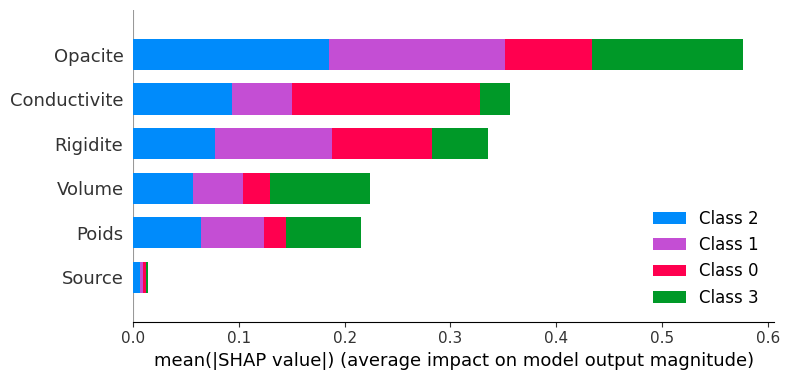


Importance SHAP (agrégée) :
Opacite         0.1443
Conductivite    0.0891
Rigidite        0.0840
Volume          0.0559
Poids           0.0538
Source          0.0035
dtype: float64


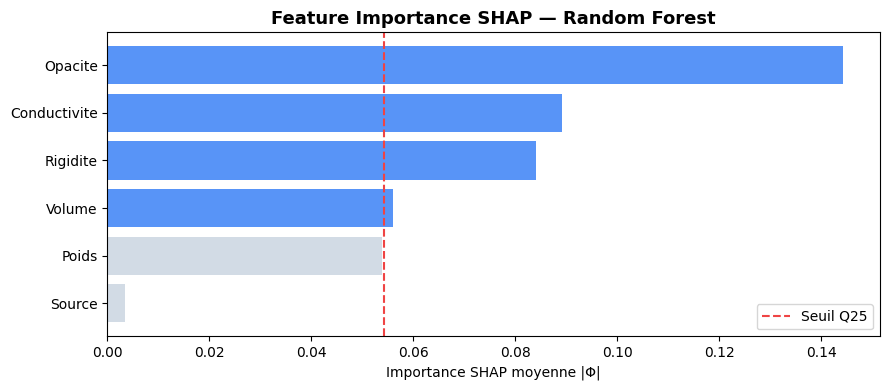

In [34]:
if SHAP_AVAILABLE:
    print("=== SHAP Feature Importance ===")

    # Entraîner RF pour SHAP (si best n'est pas RF)
    model_rf_shap = RandomForestClassifier(random_state=42, class_weight='balanced')
    model_rf_shap.fit(X_train_scaled, y_train)

    explainer  = shap.TreeExplainer(model_rf_shap)
    shap_values = explainer.shap_values(X_test_scaled)

    # Gestion multi-classe
    sv = shap_values[0] if isinstance(shap_values, list) else shap_values

    # ── SHAP Summary Plot (bar) ──
    print("\nSHAP — Importance globale (bar plot) :")
    shap.summary_plot(sv, X_test_scaled, feature_names=X.columns.tolist(),
                      plot_type="bar", show=True)

    

    # Calcul de l'importance agrégée
    if sv.ndim == 3:
        importance_arr = np.abs(sv).mean(axis=(0, 2))
    else:
        importance_arr = np.abs(sv).mean(axis=0)

    shap_importance = pd.Series(importance_arr, index=X.columns).sort_values(ascending=False)

    print("\nImportance SHAP (agrégée) :")
    print(shap_importance.round(4))

   # Palette couleurs (à ajouter)
PALETTE = ['#3B82F6', '#10B981', '#EF4444']

# ── Graphique SHAP importance bar custom ──
fig, ax = plt.subplots(figsize=(9, 4))

threshold = shap_importance.quantile(0.25)

colors = [
    PALETTE[0] if v > threshold else '#CBD5E1'
    for v in shap_importance.values
]

bars = ax.barh(
    shap_importance.index[::-1],
    shap_importance.values[::-1],
    color=colors[::-1],
    alpha=0.85
)

ax.axvline(
    threshold,
    color=PALETTE[2],
    linestyle='--',
    label='Seuil Q25'
)

ax.set_xlabel("Importance SHAP moyenne |Φ|")
ax.set_title("Feature Importance SHAP — Random Forest", fontsize=13, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()


##  Tuning des Hyperparamètres

### 5.1 — GridSearchCV 

In [35]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

print("\n=== GRIDSEARCH Random Forest ===")

# paramètres (réduits pour éviter lenteur)
parameters = {
    'n_estimators': [100, 150],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

# modèle
model = RandomForestClassifier(random_state=42, class_weight='balanced')

# GridSearch (style prof)
clf = GridSearchCV(
    model,
    parameters,
    scoring='f1_weighted',
    cv=5
)

grille = clf.fit(X_train_scaled, y_train)

# meilleurs paramètres
print("Best params:", grille.best_params_)
print("Best CV score:", grille.best_score_)

# prédiction
y_pred_rf_grid = grille.predict(X_test_scaled)

# métriques
rf_grid_acc = accuracy_score(y_test, y_pred_rf_grid)
rf_grid_prec = precision_score(y_test, y_pred_rf_grid, average='weighted')
rf_grid_rec = recall_score(y_test, y_pred_rf_grid, average='weighted')
rf_grid_f1 = f1_score(y_test, y_pred_rf_grid, average='weighted')

print('Confusion matrix RF \n', confusion_matrix(y_test, y_pred_rf_grid))
print('Accuracy RF', rf_grid_acc)
print('Precision RF', rf_grid_prec)
print('Recall RF', rf_grid_rec)
print('F1-score RF', rf_grid_f1)


=== GRIDSEARCH Random Forest ===
Best params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 150}
Best CV score: 0.9721830822767601
Confusion matrix RF 
 [[325   0   0   0]
 [  0 315   0   0]
 [ 14  13 419  15]
 [  0   0   0 358]]
Accuracy RF 0.9712131596984236
Precision RF 0.972376033003469
Recall RF 0.9712131596984236
F1-score RF 0.9708229140809052


### 5.2 — Optuna (Bayesian Optimization / TPE)

> **Optuna** utilise le TPE (Tree-structured Parzen Estimator) pour explorer intelligemment  
> l'espace des hyperparamètres, bien plus efficace que la grille exhaustive pour les grands espaces.

In [36]:
import optuna
from sklearn.model_selection import cross_val_score

print("\n=== Optuna - Random Forest ===")

def objective(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
    }

    model = RandomForestClassifier(
        **params,
        random_state=42,
        class_weight='balanced'
    )

    score = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,  # plus rapide
        scoring='f1_weighted'
    ).mean()

    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)  # rapide

best_params = study.best_params

best_rf_opt = RandomForestClassifier(
    **best_params,
    random_state=42,
    class_weight='balanced'
)

best_rf_opt.fit(X_train_scaled, y_train)

y_pred_opt = best_rf_opt.predict(X_test_scaled)

# métriques
opt_acc = accuracy_score(y_test, y_pred_opt)
opt_prec = precision_score(y_test, y_pred_opt, average='weighted')
opt_rec = recall_score(y_test, y_pred_opt, average='weighted')
opt_f1 = f1_score(y_test, y_pred_opt, average='weighted')

print("\nBest Optuna params:", best_params)
print("Best CV F1:", study.best_value)
print("Test F1:", opt_f1)
print("Test Acc:", opt_acc)

[I 2026-05-06 18:20:17,319] A new study created in memory with name: no-name-8d62610f-586a-4e2c-8b1b-a49741179f2c



=== Optuna - Random Forest ===


[I 2026-05-06 18:20:18,780] Trial 0 finished with value: 0.9700764816698138 and parameters: {'n_estimators': 136, 'max_depth': 6, 'min_samples_split': 9}. Best is trial 0 with value: 0.9700764816698138.
[I 2026-05-06 18:20:19,633] Trial 1 finished with value: 0.9721874725623589 and parameters: {'n_estimators': 64, 'max_depth': 11, 'min_samples_split': 2}. Best is trial 1 with value: 0.9721874725623589.
[I 2026-05-06 18:20:20,206] Trial 2 finished with value: 0.9694666632967474 and parameters: {'n_estimators': 53, 'max_depth': 5, 'min_samples_split': 3}. Best is trial 1 with value: 0.9721874725623589.
[I 2026-05-06 18:20:21,461] Trial 3 finished with value: 0.9711600434517873 and parameters: {'n_estimators': 97, 'max_depth': 12, 'min_samples_split': 2}. Best is trial 1 with value: 0.9721874725623589.
[I 2026-05-06 18:20:22,947] Trial 4 finished with value: 0.9714393866189182 and parameters: {'n_estimators': 98, 'max_depth': 14, 'min_samples_split': 9}. Best is trial 1 with value: 0.9721


Best Optuna params: {'n_estimators': 137, 'max_depth': 11, 'min_samples_split': 3}
Best CV F1: 0.9723389692409778
Test F1: 0.9708229140809052
Test Acc: 0.9712131596984236


### 5.3 — Comparaison : Baseline vs GridSearch vs Optuna

In [37]:
print("\n=== COMPARAISON FINALE TUNING ===")

comparison = pd.DataFrame({
    'Modèle': [
        'Random Forest (Baseline)',
        'Random Forest (GridSearch)',
        'Random Forest (Optuna)'
    ],
    'F1-score': [
        rf_f1,        # baseline
        rf_grid_f1,   # grid
        opt_f1        # optuna
    ],
    'Accuracy': [
        rf_acc,
        rf_grid_acc,
        opt_acc
    ]
}).sort_values('F1-score', ascending=False)

display(comparison)


=== COMPARAISON FINALE TUNING ===


,Modèle,F1-score,Accuracy
0,Random Forest (Baseline),0.971528,0.971899
1,Random Forest (GridSearch),0.970823,0.971213
2,Random Forest (Optuna),0.970823,0.971213


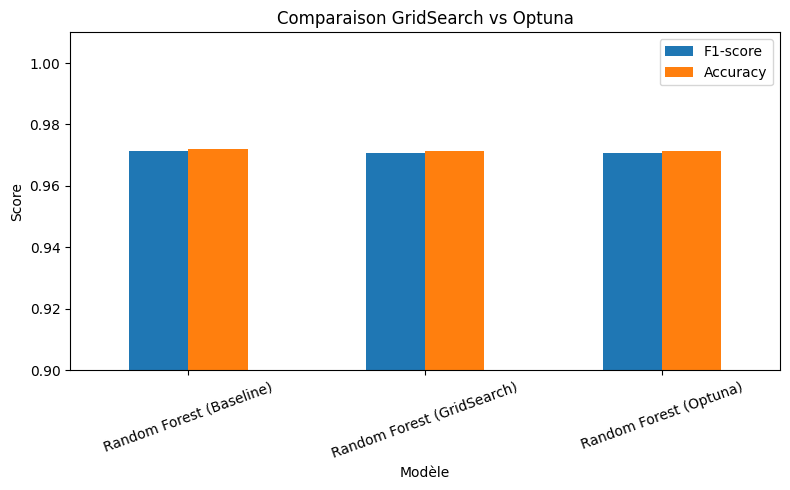

In [38]:
comparison.set_index('Modèle').plot(kind='bar', figsize=(8,5))
plt.title("Comparaison GridSearch vs Optuna")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.ylim(0.9, 1.01)
plt.tight_layout()
plt.show()